In [6]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Class counts from Train split
class_names = ['Earthquake', 'Fire', 'Flood', 'Normal']
class_counts = np.array([1927, 3509, 4063, 3900])
total = class_counts.sum()

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(4),
    y=np.repeat(np.arange(4), class_counts)
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", {class_names[i]: round(v, 4) for i, v in class_weight_dict.items()})

Class weights: {'Earthquake': np.float64(1.7383), 'Fire': np.float64(0.9546), 'Flood': np.float64(0.8245), 'Normal': np.float64(0.8589)}


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

# Base model (pretrained, frozen)
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# Custom head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

In [9]:
# Re-download AIDERv2 dataset
!pip install zenodo_get -q
!zenodo_get 10891054 -o /content/AIDER_raw

import zipfile, os

for split in ['Train', 'Val', 'Test']:
    print(f"Extracting {split}.zip...")
    with zipfile.ZipFile(f'/content/AIDER_raw/{split}.zip', 'r') as z:
        z.extractall('/content/AIDER')
    print(f"{split} done.")

# Verify
print("\n--- Verification ---")
for split in ['Train', 'Val', 'Test']:
    for cls in ['Earthquake', 'Fire', 'Flood', 'Normal']:
        path = f'/content/AIDER/{split}/{cls}'
        count = len(os.listdir(path))
        print(f"{split}/{cls}: {count} images")

INFO: Output directory: /content/AIDER_raw
INFO: Title: AIDERv2 (Aerial Image Dataset for Emergency Response Applications)
INFO: Total size: 1.5 GB
INFO: Number of files: 3
INFO: Train.zip is already downloaded correctly.
INFO: Test.zip is already downloaded correctly.
INFO: Val.zip is already downloaded correctly.
SUCCESS: All specified files have been processed.
Extracting Train.zip...
Train done.
Extracting Val.zip...
Val done.
Extracting Test.zip...
Test done.

--- Verification ---
Train/Earthquake: 1927 images
Train/Fire: 3509 images
Train/Flood: 4063 images
Train/Normal: 3900 images
Val/Earthquake: 239 images
Val/Fire: 439 images
Val/Flood: 505 images
Val/Normal: 487 images
Test/Earthquake: 239 images
Test/Fire: 436 images
Test/Flood: 502 images
Test/Normal: 477 images


In [10]:
import tensorflow as tf

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
BASE       = '/content/AIDER'

train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{BASE}/Train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f'{BASE}/Val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{BASE}/Test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

def preprocess(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

train_ds = train_ds.map(preprocess).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess).prefetch(AUTOTUNE)

Found 13399 files belonging to 4 classes.
Found 1670 files belonging to 4 classes.
Found 1654 files belonging to 4 classes.


In [11]:
import os

DRIVE_MODEL_DIR = '/content/drive/MyDrive/Project43_DisasterSeverity/models/'
LOG_DIR         = '/content/drive/MyDrive/Project43_DisasterSeverity/logs/'

callbacks_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(DRIVE_MODEL_DIR, 'efficientnet_phase1_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        os.path.join(LOG_DIR, 'phase1_log.csv')
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=os.path.join(LOG_DIR, 'phase1_tb')
    )
]

In [12]:
history_phase1 = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1
)

Epoch 1/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2409 - auc: 0.4998 - loss: 1.4118 - precision: 0.2551 - recall: 0.0022
Epoch 1: val_accuracy improved from None to 0.29162, saving model to /content/drive/MyDrive/Project43_DisasterSeverity/models/efficientnet_phase1_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Project43_DisasterSeverity/models/efficientnet_phase1_best.h5
419/419 ━━━━━━━━━━━━━━━━━━━━ 105s 155ms/step - accuracy: 0.2467 - auc: 0.4963 - loss: 1.3954 - precision: 0.2564 - recall: 7.4632e-04 - val_accuracy: 0.2916 - val_auc: 0.5277 - val_loss: 1.3853 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2835 - auc: 0.5267 - loss: 1.3888 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: val_accuracy did not improve from 0.29162
419/419 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.2727 - auc: 0.5175 - loss: 1.3865 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.2916 - val_auc: 0.5277 - val_loss: 1.3857 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2737 - auc: 0.5143 - loss: 1.3876 - precision: 0.0000e+00 - recall: 0.00

In [13]:
model.save(os.path.join(DRIVE_MODEL_DIR, 'efficientnet_phase1.h5'))
print("Phase 1 model saved.")

Phase 1 model saved.


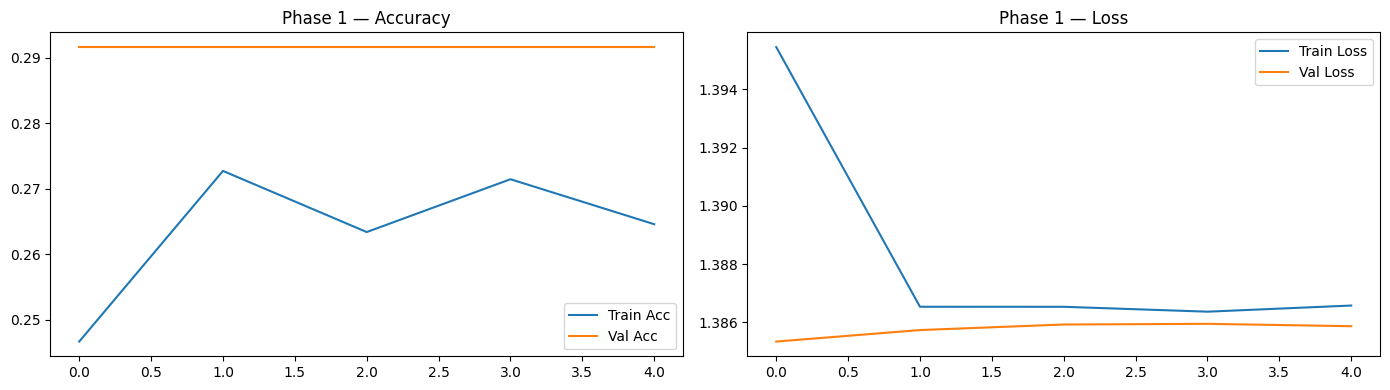

In [14]:
import matplotlib.pyplot as plt

def plot_history(history, title='Phase 1'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{title} — Accuracy'); ax1.legend()
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} — Loss'); ax2.legend()
    plt.tight_layout(); plt.show()

plot_history(history_phase1)